# P1 · 08 — Capstone: the full bake-off & a defensible forecast

Everything from P1, assembled into the workflow you'd run at work — now with the
**complete** classical slate (baselines, ETS, SARIMA, Theta, Prophet, ARIMAX):

1. **Backtest** every candidate on identical rolling-origin folds.
2. **Select** by MASE.
3. **Refit the winner on all data** and forecast with an interval.
4. **Interpret & caveat** — what could break this.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

import logging
for _n in ("cmdstanpy", "prophet"):                 # silence the Stan backend
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.disabled = True
from src import baselines as B, backtest as bt, classical as C
q = data.load_quarterly(); nsa = q["gdp_nsa"]

candidates = {
    "seasonal_naive(4)":     B.seasonal_naive(4),
    "drift":                 B.drift,
    "Holt-Winters":          C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4),
    "Holt-Winters (damped)": C.ets_forecaster(trend="add", seasonal="add",
                                              seasonal_periods=4, damped_trend=True),
    "SARIMA(1,1,1)(0,1,0)4": C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4)),
    "SARIMA(1,1,1)(1,1,1)4": C.sarima_forecaster((1, 1, 1), (1, 1, 1, 4)),
    "Theta":                 C.theta_forecaster(period=4),
    "Prophet":               C.prophet_forecaster(),
    "ARIMAX Fourier(2)":     C.arimax_forecaster((1, 1, 1), use_fourier=True, fourier_order=2),
}

### 1–2. Backtest & select (step=2 — Prophet refits are slow)

In [2]:
board = bt.compare(nsa, candidates, initial=40, h=4, step=2, season_length=4)
print(board.round(3).to_string())
winner = board.index[0]
print("\nWinner by MASE:", winner)

Importing plotly failed. Interactive plots will not work.


                               MAE         RMSE   MAPE  sMAPE   MASE
SARIMA(1,1,1)(0,1,0)4  1876575.237  3763259.428  3.453  3.467  0.573
Holt-Winters           1991129.585  3558267.177  3.626  3.549  0.608
Holt-Winters (damped)  2130783.863  3422589.067  3.737  3.671  0.650
SARIMA(1,1,1)(1,1,1)4  2146203.924  3961534.665  3.895  3.918  0.655
Prophet                2387811.499  3563751.488  4.190  4.133  0.729
Theta                  2404556.269  3252882.922  4.314  4.259  0.734
ARIMAX Fourier(2)      3188801.006  4044734.875  5.501  5.554  0.973
drift                  3350276.385  4721802.946  5.689  5.545  1.022
seasonal_naive(4)      4143994.228  4656857.645  7.216  7.389  1.265

Winner by MASE: SARIMA(1,1,1)(0,1,0)4


### 3. Refit the winner on ALL data and forecast 8 quarters ahead

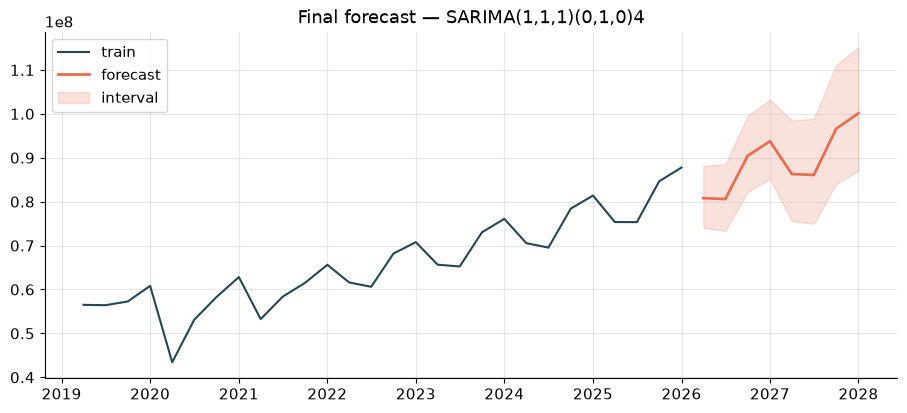

,forecast,low95,high95
2026Q2,80799934.0,74079481.0,88130064.0
2026Q3,80598219.0,73335713.0,88579937.0
2026Q4,90463970.0,82196422.0,99563092.0
2027Q1,93762101.0,85166865.0,103224788.0
2027Q2,86300639.0,75593322.0,98524578.0
2027Q3,86079173.0,74958827.0,98849252.0
2027Q4,96613023.0,84029661.0,111080731.0
2028Q1,100134128.0,87065732.0,115164064.0


In [3]:
H = 8
future = pd.period_range(nsa.index.max() + 1, periods=H, freq="Q")
if winner.startswith("SARIMA"):
    # parse the order tuples back out of the winning name
    import re
    nums = [int(n) for n in re.findall(r"\d+", winner)]
    order, sorder = tuple(nums[:3]), tuple(nums[3:7])
    mean, lo, hi = C.sarima_forecast_pi(nsa, H, order=order, seasonal_order=sorder)
else:  # a non-SARIMA winner -> approximate PI via the backtest residual spread
    f = candidates[winner]
    mean = f(nsa, H)
    res = bt.rolling_origin(nsa, f, initial=40, h=4, step=2)
    sd = (res["y_true"] - res["y_pred"]).std()
    lo, hi = mean - 1.96 * sd, mean + 1.96 * sd

fc = pd.Series(np.asarray(mean), index=future)
lo = pd.Series(np.asarray(lo), index=future); hi = pd.Series(np.asarray(hi), index=future)
fig, ax = plt.subplots()
plots.plot_forecast(nsa.iloc[-28:], pred=fc, lower=lo, upper=hi,
                    title=f"Final forecast — {winner}", ax=ax)
plots.save(fig, "p1_final_forecast"); plt.show()

out = pd.DataFrame({"forecast": fc.round(0), "low95": lo.round(0), "high95": hi.round(0)})
out

### 4. Sanity-check the implied growth

In [4]:
# YoY implied growth of the forecast vs the historical ~6.6% trend
hist = np.log(nsa).diff(4).dropna() * 100
joined = pd.concat([nsa, fc])
implied = (np.log(joined).diff(4).dropna() * 100).iloc[-H:]
print("Historical YoY growth: mean %.1f%%, last %.1f%%" % (hist.mean(), hist.iloc[-1]))
print("Forecast implied YoY growth (next 8q):")
print(implied.round(2))

Historical YoY growth: mean 6.6%, last 7.5%
Forecast implied YoY growth (next 8q):
2026Q2    6.98
2026Q3    6.74
2026Q4    6.64
2027Q1    6.60
2027Q2    6.59
2027Q3    6.58
2027Q4    6.58
2028Q1    6.57
Freq: Q-DEC, dtype: float64


### What could break this forecast (always write this section)

* **Structural breaks.** COVID (2020 Q2, −26% YoY) shows the model assumes the
  past regime continues. A demonetisation, a pandemic, or a base-year revision
  invalidates it. Classical models *cannot* foresee shocks.
* **Short sample.** 88 quarters is little; the seasonal pattern and trend are
  estimated from ~20 years. Treat far-horizon points with suspicion.
* **Point vs density.** We report a 95% interval, but it assumes the residual
  distribution is stable and (for SARIMA) roughly Gaussian-in-log. Project 3
  replaces this with proper probabilistic / conformal intervals.
* **Only deterministic exog.** ARIMAX (07) used Fourier terms and an event dummy —
  *known* external facts. We used no **data-driven** drivers (rates, monsoon, global
  demand). Project 2 adds feature-based ML to bring those in.

### The office recipe (reusable checklist)

1. Plot the series; **log** if it grows multiplicatively.
2. **Decompose** and measure seasonal strength.
3. **Test stationarity** (ADF + KPSS) → differencing orders.
4. Establish **baselines** + pick a **metric** (MASE) + a **backtest** (rolling origin).
5. Try a **slate** — ETS, (S)ARIMA, Theta, Prophet, ARIMAX; **diagnose residuals**.
6. **Select by backtest**, refit on all data, forecast **with intervals**.
7. Write the **caveats**. A forecast without an interval and a caveat is a guess.

---
**Project 1 complete.** Across 8 notebooks you can now diagnose, transform, model
(the full classical slate), evaluate honestly, and defend a forecast. Project 2
moves to feature-based machine-learning forecasting.